# Proximal Policy Optimization

### Import libraries

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical, Normal
import numpy as np

### Select GPU

In [2]:
# Device selection (CUDA, MPS, or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

print(f"Using device: {device}")

Using device: cuda


### Define PPO agent class

In [ ]:
class PPOAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        
        # Critic network, estimates state value V(s)
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        # Actor network, outputs action probabilities
        self.actor = nn.Sequential(
            nn.Linear(state_dim, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, action_dim)
        )
        

    def get_action_and_value(self, x, action=None):
        value = self.critic(x)
        logits = self.actor(x)# raw scores for each action
        probs = Categorical(logits=logits) #convert to probabilities
        if action is None:
            action = probs.sample()
        return action, probs.log_prob(action), probs.entropy(), value


### Train function

In [ ]:

import json
import highway_env

def train_ppo(episodes=1000):
    env = gym.make('highway-v0') # load the env
    agent = PPOAgent(np.prod(env.observation_space.shape), #flatten observation space by taking the product
                     env.action_space.n).to(device)
    optimizer = optim.Adam(agent.parameters(), lr=3e-4)
    eps_clip = 0.2

    ppo_rewards_history = []
    ppo_loss_history = []
    
    # Simple training loop (collecting 1 episode per update for clarity)
    for ep in range(episodes):
        state, _ = env.reset()
        states, actions, logprobs, rewards, values = [], [], [], [], []
        
        # 1. Collection phase
        while True:
            st = torch.from_numpy(state.flatten()).float().to(device).unsqueeze(0)
            action, logprob, _, value = agent.get_action_and_value(st)
            
            next_state, reward, term, trunc, _ = env.step(action.item())
            
            states.append(st)
            actions.append(action)
            logprobs.append(logprob)
            rewards.append(reward)
            values.append(value)
            
            state = next_state
            if term or trunc: break
            
        # 2. Compute Advantages
        returns, g = [], 0
        for r in reversed(rewards):
            g = r + 0.99 * g
            returns.insert(0, g)
        # convert returns to float32 tensor and move to device
        returns = np.array(returns, dtype=np.float32)
        returns = torch.tensor(returns).to(device).unsqueeze(1)
        values = torch.cat(values)
        advantages = (returns - values).detach()
        
        # 3. Update phase (Standard PPO update)
        curr_states = torch.cat(states)
        curr_actions = torch.cat(actions)
        curr_logprobs = torch.cat(logprobs).detach()
        
        _, new_logprobs, entropy, new_values = agent.get_action_and_value(curr_states, curr_actions)
        ratio = torch.exp(new_logprobs - curr_logprobs)
        
        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1-eps_clip, 1+eps_clip) * advantages
        
        loss = -torch.min(surr1, surr2).mean() + 0.5 * nn.MSELoss()(new_values, returns) - 0.01 * entropy.mean()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        ppo_rewards_history.append(sum(rewards))
        ppo_loss_history.append(loss.item())
        
        if ep % 20 == 0:
            print(f"Ep {ep} | Reward: {sum(rewards)}")
    
    print("Training completed.")
    with open('ppo_history.json', 'w') as f:
        json.dump({'rewards': ppo_rewards_history, 'losses': ppo_loss_history}, f)
    return agent, ppo_rewards_history, ppo_loss_history

agent, ppo_rewards_history, ppo_loss_history = train_ppo()

Ep 0 | Reward: 20.60822376787308
Ep 20 | Reward: 23.17873302990474
Ep 40 | Reward: 6.547583887520037
Ep 60 | Reward: 9.106284824773141
Ep 80 | Reward: 12.236216070613597
Ep 100 | Reward: 4.673849808792834
Ep 120 | Reward: 29.696686145822664
Ep 140 | Reward: 18.97585497691205
Ep 160 | Reward: 6.05726909848925
Ep 180 | Reward: 13.060475528363316
Ep 200 | Reward: 10.36783451461669
Ep 220 | Reward: 12.105169460119464
Ep 240 | Reward: 25.613421561947618
Ep 260 | Reward: 20.090735454966907
Ep 280 | Reward: 2.960150230291103
Ep 300 | Reward: 7.91485341845906
Ep 320 | Reward: 4.358919087036114
Ep 340 | Reward: 25.13200789797862
Ep 360 | Reward: 29.40157200103579
Ep 380 | Reward: 28.78303689026532
Ep 400 | Reward: 29.247811980864363
Ep 420 | Reward: 21.24899148383676
Ep 440 | Reward: 29.1366741130292
Ep 460 | Reward: 29.22748065133005
Ep 480 | Reward: 28.805258331980024
Ep 500 | Reward: 29.294143996505166
Ep 520 | Reward: 29.5148712484857
Ep 540 | Reward: 29.382238346494375
Ep 560 | Reward: 7.4

### Make loss and reward curves

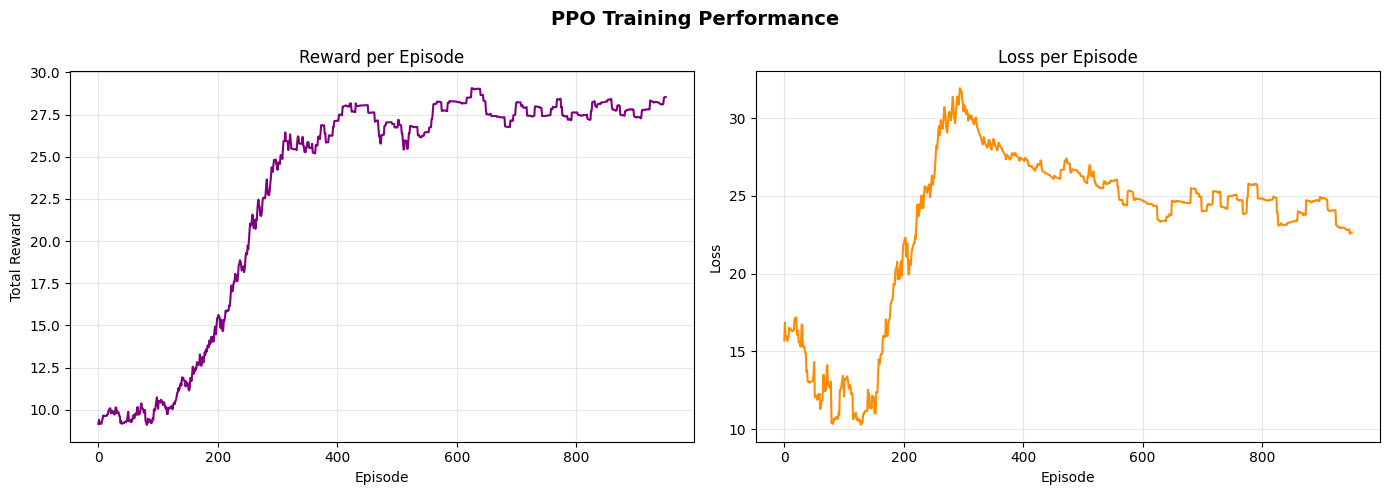

In [8]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open('ppo_history.json', 'r') as f:
    ppo = json.load(f)

ppo_rewards = ppo['rewards']
ppo_losses = ppo['losses']

def smooth(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PPO Training Performance', fontsize=14, fontweight='bold')

axes[0].plot(smooth(ppo_rewards), color='purple')
axes[0].set_title('Reward per Episode')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].grid(True, alpha=0.3)

axes[1].plot(smooth(ppo_losses), color='darkorange')
axes[1].set_title('Loss per Episode')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ppo_performance.png', dpi=150)
plt.show()

### Evaluation Metrics

In [ ]:
import json
import numpy as np

with open('ppo_history.json', 'r') as f:
    ppo = json.load(f)

ppo_rewards = ppo['rewards']
ppo_losses = ppo['losses']

print("Average reward of last 100 episodes: ", np.mean(ppo_rewards[-100:]))
print("Maximum reward ", np.max(ppo_rewards))
print("Average reward of last 100 episodes: ", np.mean(ppo_losses[-100:]))

27.948171214214696
36.83239452976942
23.746978034973143
